In [1]:
import numpy as np
import pandas as pd

from utils.rule_based_controller import RuleBasedController

from envs.bess_env import BatteryEnv
from utils.csv_handler import load_price_data, load_demand_data
from utils.plot_handler import plot_bess_rollout
from utils.eval_handler import evaluate_financials, evaluate_rollout
from utils.forecast_scenario import ForecastScenarioGenerator

In [2]:
# === Load training data: full November 2024 ===
dfp_train, price_train, ts_train = load_price_data(
    csv_path="../../data/electricity_price/dayahead_2024_11.csv",
    resolution="15min",
)

dfd_train, demand_train, _ = load_demand_data(
    csv_path="../../data/electricity_demand/demand_2024_11.csv",
    resolution="15min",
    demand_scale=1e-7, # Small-consumer / household-like load level
)

# === Load evaluation data: first week of November 2025 ===
dfp_eval, price_eval, ts_eval = load_price_data(
    csv_path="../../data/electricity_price/dayahead_2025_11.csv",
    resolution="15min",
    time_range=("2025-11-01", "2025-11-07"),
)

dfd_eval, demand_eval, _ = load_demand_data(
    csv_path="../../data/electricity_demand/demand_2025_11.csv",
    resolution="15min",
    time_range=("2025-11-01", "2025-11-07"),
    demand_scale=1e-7, # Small-consumer / household-like load level
)

print(len(price_eval), "time steps in a week (should be 672)")
print("Week from", ts_train[0], "to", ts_train[-1])

672 time steps in a week (should be 672)
Week from 2024-11-01 00:00:00+01:00 to 2024-11-30 23:45:00+01:00


Episode finished after 672 steps
=== Financial Summary ===
Total revenue    (EUR): -76.395
Degradation cost (EUR): 0.160
Penalty cost     (EUR): 0.000
Total reward     (EUR): -76.555


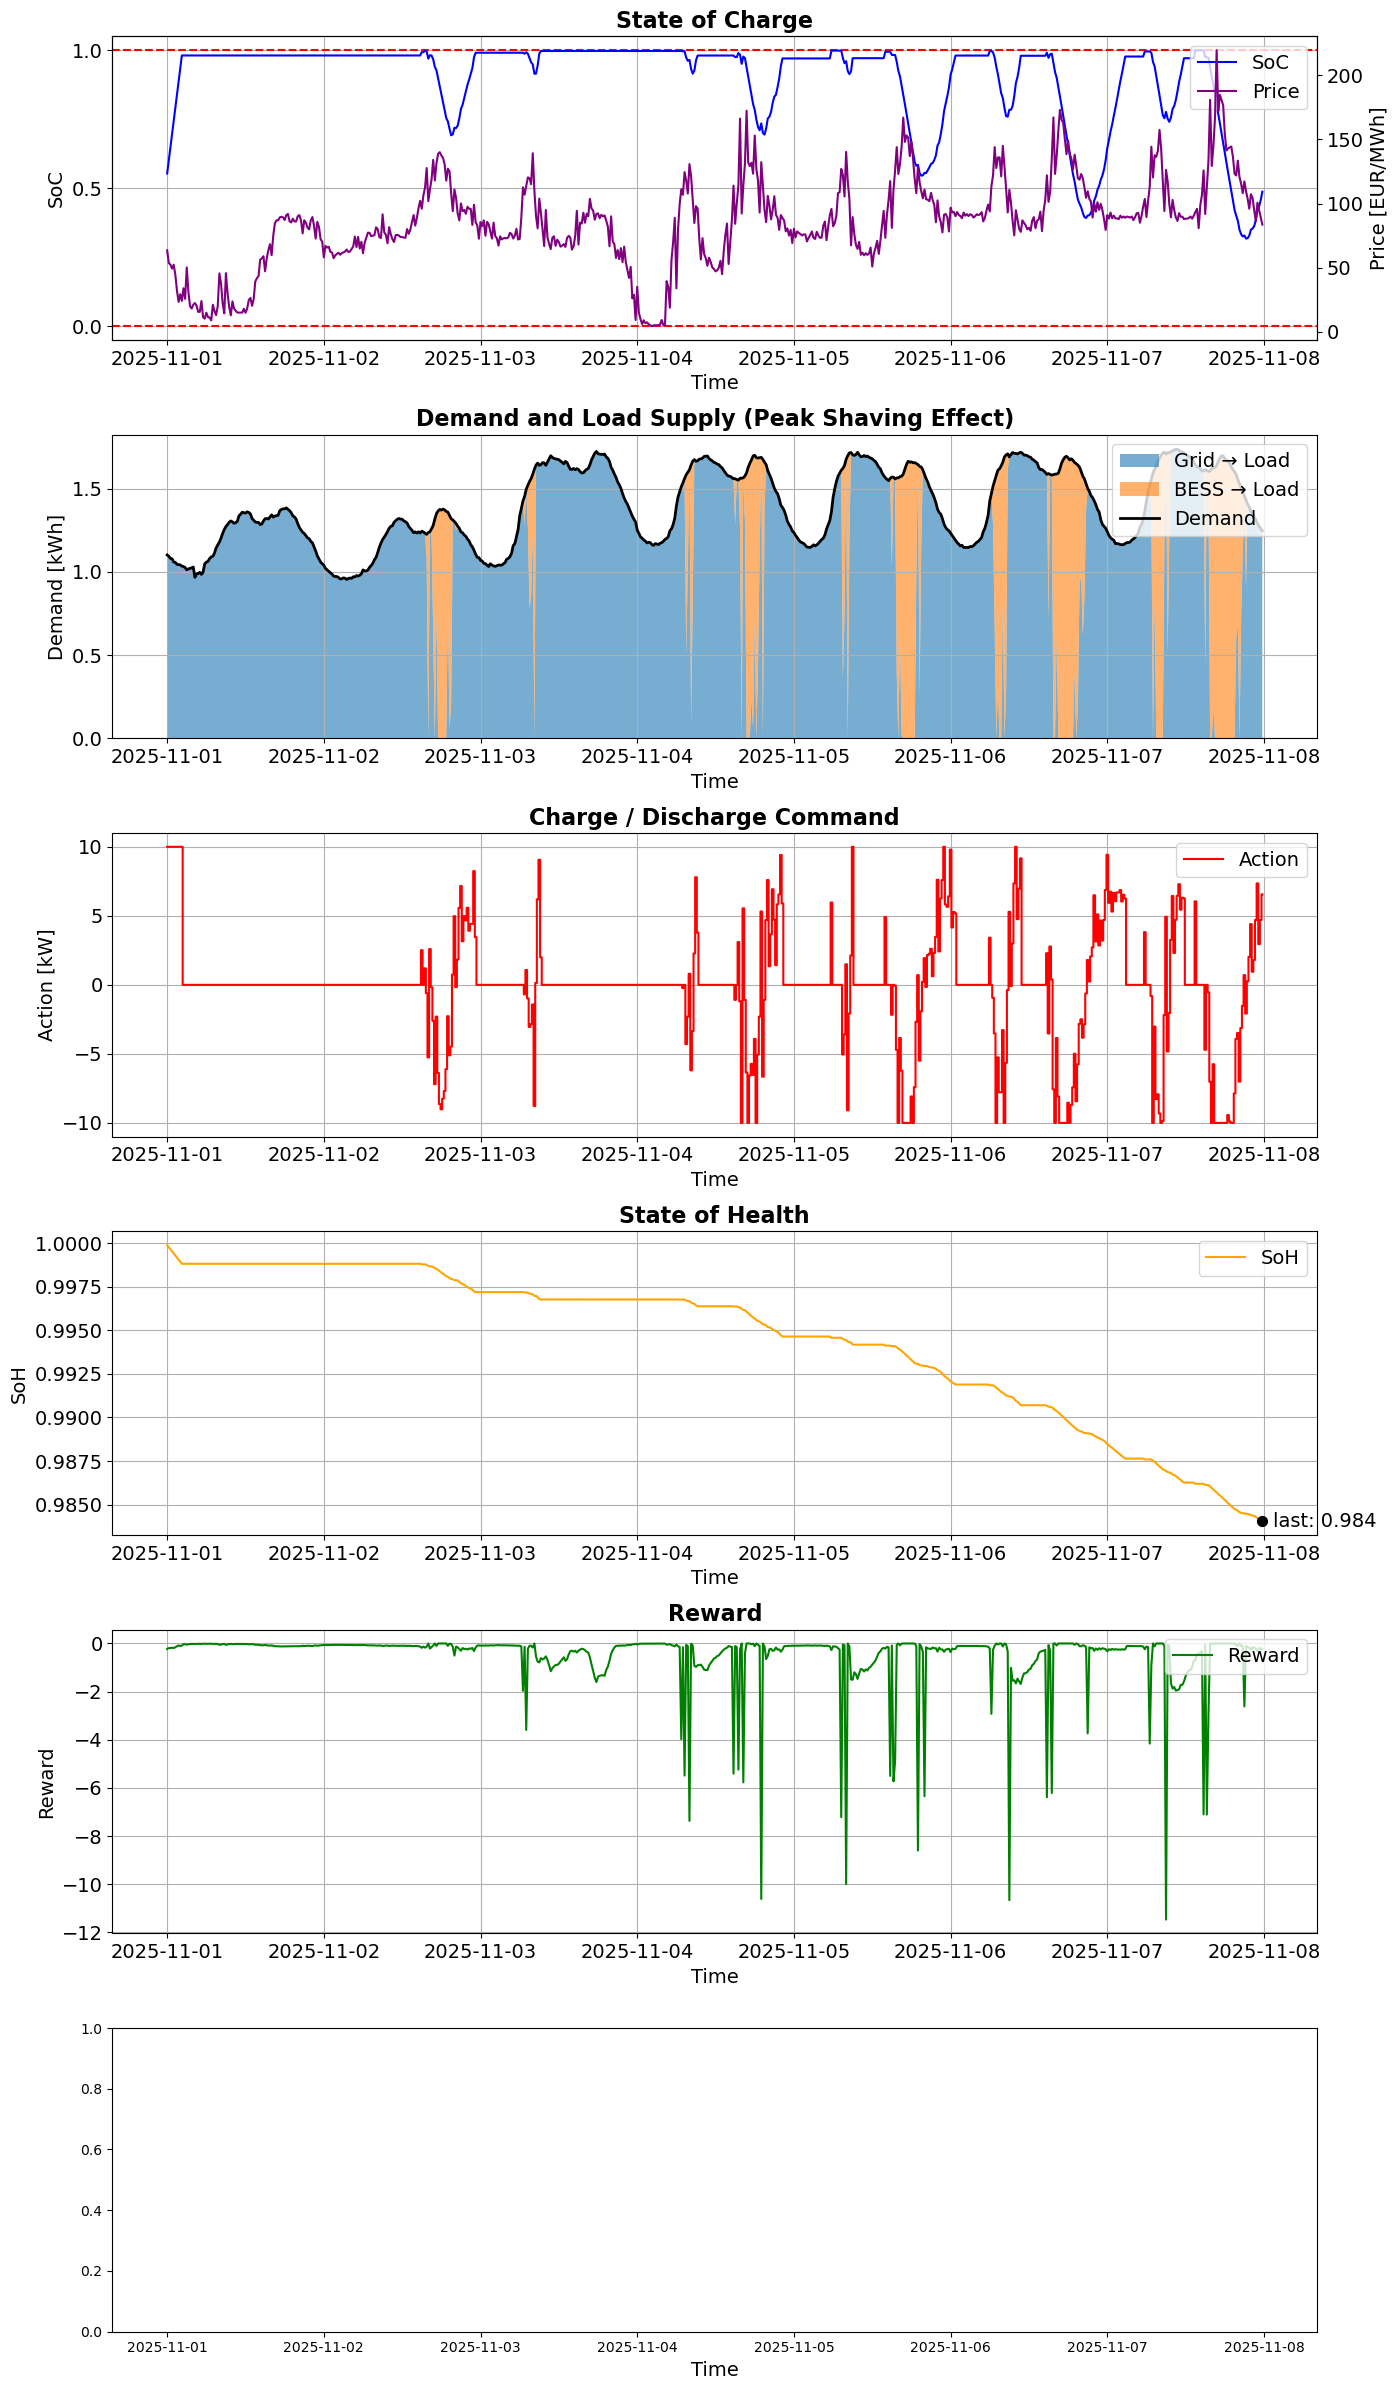

In [3]:
forecast_horizon_hours=3.0 # 3h
dt_hours=0.25 # 15 min
H = int(round(forecast_horizon_hours / dt_hours))  # 3h forecast, 15 min steps → 12 steps

# --------------------------------------------------
# Price forecast uncertainty scenarios (deterministic)
# --------------------------------------------------
price_scenario_gen = ForecastScenarioGenerator(
    horizon_steps=H,
    sigma0=0.01,       # small uncertainty for near future
    sigmaH=0.06,       # larger uncertainty for further future
    schedule="sqrt",   # realistic growth
    base_seed=1234,    # IMPORTANT: same seed = same scenarios
)

# --------------------------------------------------
# Demand forecast uncertainty scenarios (deterministic)
# --------------------------------------------------
demand_scenario_gen = ForecastScenarioGenerator(
    horizon_steps=H,
    sigma0=0.005,
    sigmaH=0.02,
    schedule="sqrt",
    base_seed=5678,
)

# Create evaluation environment on first week of November
eval_env = BatteryEnv(
    price_series=price_eval,
    demand_series=demand_eval,
    timestamps=ts_eval,
    dt_hours=dt_hours,              
    capacity_kWh=50.0,
    p_max_kW=10.0,
    use_discrete_actions=False,    # continuous for RB
    use_price_forecast=True,
    use_demand_forecast=True,
    forecast_horizon_hours=forecast_horizon_hours,
    episode_days=7.0,              # one-week logical episode
    random_start=True,  
    random_seed=45,
    price_scenario_gen=price_scenario_gen,
    demand_scenario_gen=demand_scenario_gen,
    allow_grid_export=False,       # Peak shaving mode
)

# Instantiate Rule Based Controller
rb_controller_cont = RuleBasedController(env=eval_env, price_history=price_train) 

results = evaluate_rollout(
    model=rb_controller_cont,
    env=eval_env,
)

evaluate_financials(
    revenue_list=results["revenue"],
    deg_cost_list=results["deg_cost"],
    penalty_list=results["penalty"],
)

plot_bess_rollout(
    soc_list=results["soc"],
    soh_list=results["soh"],
    reward_list=results["reward"],
    price_list=results["price_true"],
    demand_list=results["demand_true"],
    action_list=results["action"],
    timestamps=ts_eval,

    grid_import_load_kWh_list=results["grid_import_load_kWh"],
    supplied_to_load_kWh_list=results["supplied_to_load_kWh"],
)